# Приведение признаков к одному масштабу



## Зачем это нужно

Если признаки измеряются в разных единицах, один из них может численно доминировать над другими.  
Например:

- `age` — десятки
- `income` — десятки и сотни тысяч
- `distance` — единицы или доли

Это особенно важно для моделей, которые используют расстояния или чувствительны к масштабу признаков:

- kNN
- k-means
- SVM
- логистическая регрессия
- линейная регрессия с регуляризацией
- PCA


## 1. Min-Max Scaling

Переводит значения в фиксированный интервал, чаще всего **[0, 1]**.

### Формула

$$
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

### Идея
- минимальное значение станет `0`
- максимальное значение станет `1`
- остальные значения окажутся между ними

### Когда удобно
Когда нужен понятный ограниченный диапазон значений.

### Ограничение
Метод чувствителен к выбросам.

Лучше всего подходит для:
* линейной регрессии
* логистической регрессии
* SVM
* нейронных сетей
* PCA

Эти алгоритмы предполагают, что признаки имеют сопоставимые масштабы и нормальное распределение.

## 2. Standard Scaling

Этот способ центрирует признак и приводит его к стандартному отклонению 1.

### Формула

$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n}(x_i - \mu)^2}
$$
где:

- $\mu$ — среднее значение признака
- $\sigma$ — стандартное отклонение

### Идея
После преобразования:
- среднее примерно равно `0`
- стандартное отклонение примерно равно `1`

### Когда удобно
Часто используется по умолчанию для многих ML-алгоритмов.

Лучше подходит для:
* k-NN
* k-means
* нейронных сетей
* алгоритмов, основанных на расстояниях

Все признаки приводятся к одинаковому диапазону, поэтому расстояния считаются корректнее.


### Когда масштабирование вообще не нужно

Некоторые алгоритмы не чувствительны к масштабу признаков, потому что используют разбиения по порогам.

Обычно масштабирование не требуется для:
* Decision Tree
* Random Forest
* Gradient Boosting
* XGBoost
* LightGBM
* CatBoost

Деревья принимают решения вида

x<threshold

и масштаб признаков на это почти не влияет.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "age": [18, 22, 35, 47, 60],
    "income": [25000, 40000, 90000, 120000, 150000],
    "distance": [0.8, 1.2, 3.5, 7.0, 10.0]
})

df

,age,income,distance
0,18,25000,0.8
1,22,40000,1.2
2,35,90000,3.5
3,47,120000,7.0
4,60,150000,10.0


Видно, что признаки имеют очень разный масштаб:

- `age` — десятки
- `income` — десятки и сотни тысяч
- `distance` — числа порядка единиц


In [2]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df),
    columns=df.columns
)

df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df),
    columns=df.columns
)

print("Исходные данные:")
display(df)

print("Min-Max Scaling:")
display(df_minmax.round(3))

print("Standard Scaling:")
display(df_standard.round(3))

Исходные данные:


,age,income,distance
0,18,25000,0.8
1,22,40000,1.2
2,35,90000,3.5
3,47,120000,7.0
4,60,150000,10.0


Min-Max Scaling:


,age,income,distance
0,0.000,0.00,0.000
1,0.095,0.12,0.043
2,0.405,0.52,0.293
3,0.690,0.76,0.674
4,1.000,1.00,1.000


Standard Scaling:


,age,income,distance
0,-1.179,-1.273,-1.050
1,-0.923,-0.955,-0.937
2,-0.090,0.106,-0.284
3,0.679,0.743,0.709
4,1.513,1.380,1.561


## Что видно после преобразования

### Min-Max Scaling
Все значения лежат в диапазоне примерно от `0` до `1`.

### Standard Scaling
Признаки уже имеют сопоставимый масштаб:
- среднее около `0`
- разброс около `1`


In [3]:
print("Средние после Standard Scaling:")
print(df_standard.mean().round(6))

print("\nСтандартные отклонения после Standard Scaling:")
print(df_standard.std(ddof=0).round(6))

Средние после Standard Scaling:
age         0.0
income     -0.0
distance    0.0
dtype: float64

Стандартные отклонения после Standard Scaling:
age         1.0
income      1.0
distance    1.0
dtype: float64


## Короткий вывод

**Приведение к одному масштабу** нужно, чтобы признаки были сопоставимы по величине.

### Запомнить:

- **Min-Max Scaling**  
  удобно, когда нужен диапазон `[0, 1]`

- **Standard Scaling**  
  удобно как универсальный способ для многих моделей

### Важно:
Для деревьев решений, Random Forest и градиентного бустинга масштабирование обычно не так критично.


In [4]:
# Небольшое сравнение разбросов по столбцам
comparison = pd.DataFrame({
    "original_min": df.min(),
    "original_max": df.max(),
    "minmax_min": df_minmax.min(),
    "minmax_max": df_minmax.max(),
    "standard_mean": df_standard.mean(),
    "standard_std": df_standard.std(ddof=0)
})

comparison.round(3)

,original_min,original_max,minmax_min,minmax_max,standard_mean,standard_std
age,18.0,60.0,0.0,1.0,0.0,1.0
income,25000.0,150000.0,0.0,1.0,-0.0,1.0
distance,0.8,10.0,0.0,1.0,0.0,1.0


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from math import sqrt

df = pd.DataFrame({
    "name": ["A", "B", "C"],
    "age": [20, 22, 50],
    "income": [50000, 150000, 102000]
})

display(df)

,name,age,income
0,A,20,50000
1,B,22,150000
2,C,50,102000


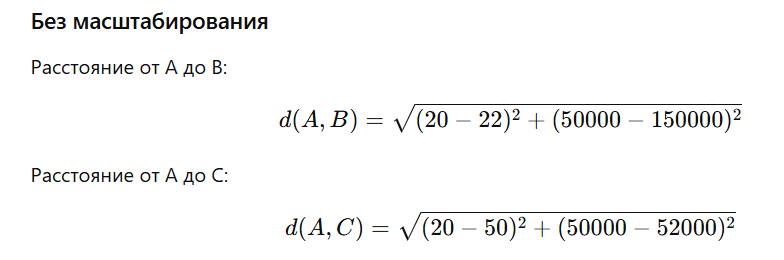

In [11]:
A = df.loc[0, ["age", "income"]].values
B = df.loc[1, ["age", "income"]].values
C = df.loc[2, ["age", "income"]].values

dist_AB = np.linalg.norm(A - B)
dist_AC = np.linalg.norm(A - C)

print("Без масштабирования:")
print("Расстояние A-B:", dist_AB)
print("Расстояние A-C:", dist_AC)

Без масштабирования:
Расстояние A-B: 100000.00002
Расстояние A-C: 52000.008653845434


In [12]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df[["age", "income"]])

A_s = scaled[0]
B_s = scaled[1]
C_s = scaled[2]

dist_AB_s = np.linalg.norm(A_s - B_s)
dist_AC_s = np.linalg.norm(A_s - C_s)

print("После масштабирования:")
print("Расстояние A-B:", dist_AB_s)
print("Расстояние A-C:", dist_AC_s)

После масштабирования:
Расстояние A-B: 2.4531874612379174
Расстояние A-C: 2.5337942655805357


In [13]:
scaled

array([[-0.77886781, -1.24074398],
       [-0.6328301 ,  1.20809282],
       [ 1.41169791,  0.03265116]])